# Intro

# 1. Imports

In [20]:
import os
import pickle
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import Counter
import matplotlib.pyplot as plt

Разучаване на научни статии и техники за построяване на препоръчващи
системи - Collaborative Filtering, Content-Based Filtering, Хибридни,
Рекурентни невронни мрежи, Автоенкодери.

Разглеждане на данните - брой наблюдения, брой и тип на характеристиките,
статистически зависимости в данните, аномалии в данните. Докладване и
анализ, илюстриран с подходящи визуализации и придружен с коментари.

# 2. Joke Ratings Dataset 1

In [21]:
jokes_1_df = pd.read_csv(os.path.join('data', 'jester_data_1.csv')) # rated at least 36 jokes
print(jokes_1_df.info())
jokes_1_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 48483 entries, 0 to 48482
Columns: 101 entries, count to 99
dtypes: float64(100), int64(1)
memory usage: 37.4 MB
None


,count,0,1,2,3,4,5,6,7,8,...,90,91,92,93,94,95,96,97,98,99
0,74,-7.82,8.79,-9.66,-8.16,-7.52,-8.50,-9.85,4.17,-8.98,...,2.82,NaN,NaN,NaN,NaN,NaN,-5.63,NaN,NaN,NaN
1,100,4.08,-0.29,6.36,4.37,-2.38,-9.66,-0.73,-5.34,8.88,...,2.82,-4.95,-0.29,7.86,-0.19,-2.14,3.06,0.34,-4.32,1.07
2,49,NaN,NaN,NaN,NaN,9.03,9.27,9.03,9.27,NaN,...,NaN,NaN,NaN,9.08,NaN,NaN,NaN,NaN,NaN,NaN
3,48,NaN,8.35,NaN,NaN,1.80,8.16,-2.82,6.21,NaN,...,NaN,NaN,NaN,0.53,NaN,NaN,NaN,NaN,NaN,NaN
4,91,8.50,4.61,-4.17,-5.39,1.36,1.60,7.04,4.61,-0.44,...,5.19,5.58,4.27,5.19,5.73,1.55,3.11,6.55,1.80,1.60


There are 48,483 users in our first dataset, each giving a rating in [-10, 10] to 100 jokes. The first column is the amount of jokes each user has rated.

We check how many users have rated more than 36 jokes.

In [22]:
sum(jokes_1_df['count'] >= 36)

48483

Indeed, all users have rated at least 36 jokes.

Next, we check the density of the DataFrame, i.e. how many ratings are different from 99 (which means a user hasn't rated the given joke).

In [23]:
ratings_valid_possible = len(jokes_1_df) * 100
ratings_valid_count = jokes_1_df['count'].sum()
print(f'Valid ratings: {ratings_valid_count} / {ratings_valid_possible} = {ratings_valid_count/ratings_valid_possible*100:.2f}%')

Valid ratings: 3519448 / 4848300 = 72.59%


The first dataset is fairly dense (72% of values are valid ratings).

<Axes: title={'center': 'Valid ratings for each joke'}, xlabel='Joke id', ylabel='Valid rating'>

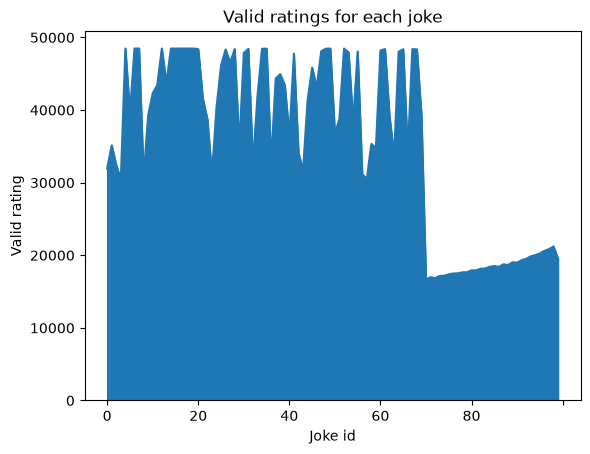

In [24]:
jokes_1_df.iloc[:, 1:][~jokes_1_df.isna()].count().plot(
    kind='area',
    title='Valid ratings for each joke',
    xlabel='Joke id',
    ylabel='Valid rating'
)

We make a KDE (Kernel Density Estimate) plot with respect to the valid ratings per columns: a statistical chart to visualize the probability distribution of valid jokes per column.

<Axes: title={'center': 'How many valid ratings are there per joke'}, ylabel='Density'>

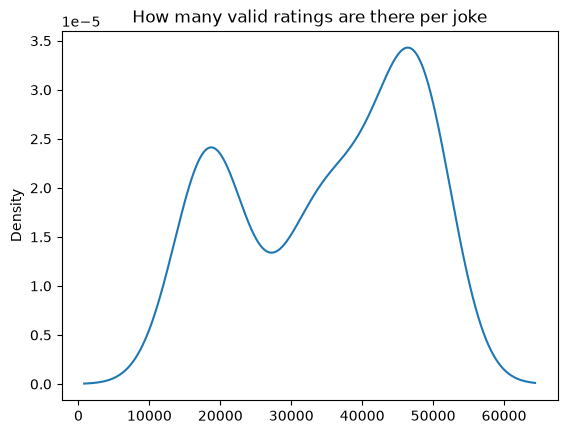

In [25]:
# "smoothed version of a histogram"
jokes_1_df.iloc[:, 1:][~jokes_1_df.isna()].count(axis=0).plot(
    kind='kde',
    title='How many valid ratings are there per joke',
)

From the KDE graph we can see that most jokes have between 20k or 48k valid ratings.

We do the same this with respect to the rows, i.e. the distribution of how many valid ratings each user has given.

<Axes: title={'center': 'Distribution of valid ratings among users'}, ylabel='Density'>

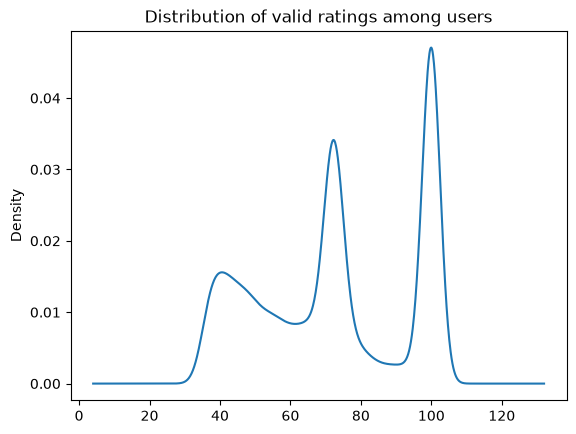

In [26]:
# "smoothed version of a histogram"
jokes_1_df.iloc[:, 1:][~jokes_1_df.isna()].count(axis=1).plot(
    kind='kde',
    title='Distribution of valid ratings among users',
)

The graph shows three prominent peeks at 40, 75 and 100, meaning most users have given either of those amounts of valid ratings to the 100 jokes in the dataset.

The next step is to look at the ratings. 

In [27]:
all_ratings_list = []

for index, row in tqdm(jokes_1_df.iterrows(), total=len(jokes_1_df)):
    r = row.iloc[1:]
    all_ratings_list.extend(r[~r.isna()])

c = Counter(all_ratings_list)
all_ratings_count_1 = sorted(c.items())

print(len(set(all_ratings_list)))

100%|██████████| 48483/48483 [00:11<00:00, 4319.33it/s]


412


There are a total of 413 unique ratings with 99 being one of them.

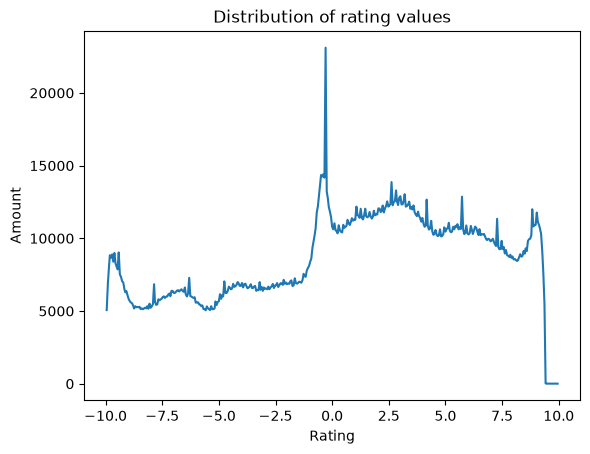

In [28]:
x_range = [r[0] for r in all_ratings_count_1][:-1]
y_range = [r[1] for r in all_ratings_count_1][:-1]
plt.plot(x_range, y_range)
plt.title('Distribution of rating values')
plt.xlabel('Rating')
plt.ylabel('Amount')
plt.show()

In [29]:
negative_ratings_amount = [amount for rating, amount in all_ratings_count_1[:-1] if rating < 0]
positive_ratings_amount = [amount for rating, amount in all_ratings_count_1[:-1] if rating > 0]

p = sum(positive_ratings_amount)
n = sum(negative_ratings_amount)
a = p + n

print(f'All ratings: {a}')
print(f'Positive ratings: {p}, {p/a*100:.2f}% of total')
print(f'Negative ratings: {n}, {n/a*100:.2f}% of total')

All ratings: 3508662
Positive ratings: 2079164, 59.26% of total
Negative ratings: 1429498, 40.74% of total


There are a total of 3508665 ratings, with most of them being around 0. There are 2079167 positive ratings, being 59.26% of the total and 1429498 negative ratings, being 40.74% of the total. Over half of jokes were rated positively.

# 3. Joke Ratings Dataset 2

In [30]:
jokes_2_df = pd.read_csv(os.path.join('data', 'jester_data_2.csv')) # rated between 15 and 35 jokes
print(jokes_2_df.info())
jokes_2_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 24938 entries, 0 to 24937
Columns: 101 entries, count to 99
dtypes: float64(100), int64(1)
memory usage: 19.2 MB
None


,count,0,1,2,3,4,5,6,7,8,...,90,91,92,93,94,95,96,97,98,99
0,26,NaN,NaN,NaN,NaN,-1.65,NaN,-0.78,6.89,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,33,NaN,NaN,NaN,NaN,-9.27,NaN,-9.17,-8.59,NaN,...,NaN,NaN,-2.77,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,16,NaN,NaN,NaN,NaN,-6.12,NaN,-7.48,-7.77,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,24,NaN,0.05,NaN,NaN,-2.82,NaN,-4.85,-0.87,NaN,...,NaN,NaN,NaN,NaN,1.84,NaN,NaN,NaN,-4.08,NaN
4,22,NaN,NaN,NaN,NaN,-4.95,NaN,6.21,2.72,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


There are 48,483 users in our first dataset, each giving a rating in [-10, 10] to 100 jokes. The first column is the amount of jokes each user has rated.

We check how many users have rated more than 36 jokes.

In [31]:
sum(jokes_2_df['count'] <= 35)

24938

Indeed, all users have rated less than 36 jokes.

Next, we check the density of the DataFrame, i.e. how many ratings are different from 99 (which means a user hasn't rated the given joke).

In [32]:
ratings_valid_possible = len(jokes_2_df) * 100
ratings_valid_count = jokes_2_df['count'].sum()
print(f'Valid ratings: {ratings_valid_count} / {ratings_valid_possible} = {ratings_valid_count/ratings_valid_possible*100:.2f}%')

Valid ratings: 616912 / 2493800 = 24.74%


The first dataset is fairly sparse (25% of values are valid ratings).

<Axes: title={'center': 'Valid ratings for each joke'}, xlabel='Joke id', ylabel='Valid rating'>

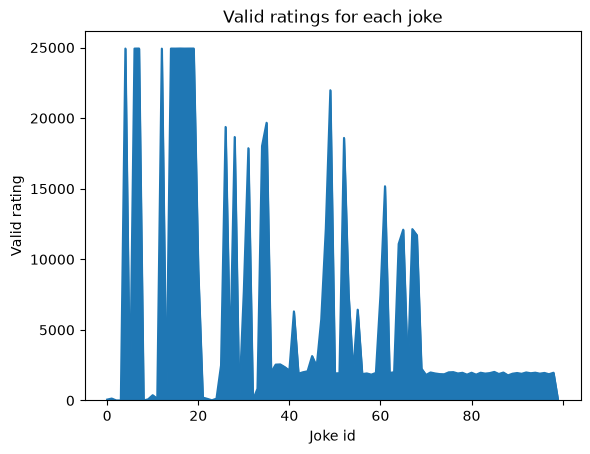

In [33]:
jokes_2_df.iloc[:, 1:][~jokes_2_df.isna()].count().plot(
    kind='area',
    title='Valid ratings for each joke',
    xlabel='Joke id',
    ylabel='Valid rating'
)

We make a KDE (Kernel Density Estimate) plot with respect to the valid ratings per columns: a statistical chart to visualize the probability distribution of valid jokes per column.

<Axes: title={'center': 'How many valid ratings are there per joke'}, ylabel='Density'>

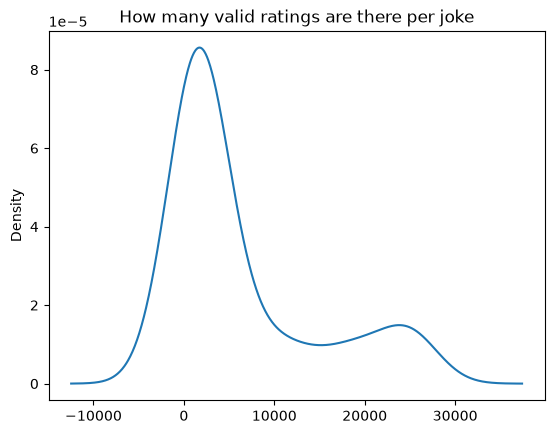

In [34]:
# "smoothed version of a histogram"
jokes_2_df.iloc[:, 1:][~jokes_2_df.isna()].count(axis=0).plot(
    kind='kde',
    title='How many valid ratings are there per joke',
)

From the KDE graph we can see that most jokes have around 1k valid ratings and a second lesser bump around 25k.

We do the same this with respect to the rows, i.e. the distribution of how many valid ratings each user has given.

<Axes: title={'center': 'Distribution of valid ratings among users'}, ylabel='Density'>

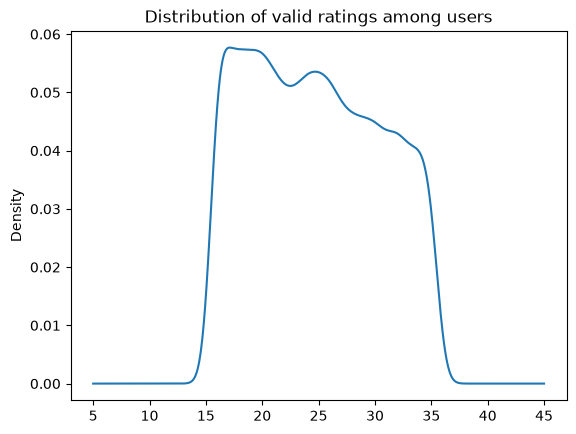

In [35]:
# "smoothed version of a histogram"
jokes_2_df.iloc[:, 1:][~jokes_2_df.isna()].count(axis=1).plot(
    kind='kde',
    title='Distribution of valid ratings among users',
)

The graph shows that most users have given between 15 and 35 valid ratings to the 100 jokes in the dataset.

The next step is to look at the ratings. 

In [36]:
all_ratings_list = []

for index, row in tqdm(jokes_2_df.iterrows(), total=len(jokes_2_df)):
    r = row.iloc[1:]
    all_ratings_list.extend(r[~r.isna()])

c = Counter(all_ratings_list)
all_ratings_count_2 = sorted(c.items())

print(len(set(all_ratings_list)))

  0%|          | 0/24938 [00:00<?, ?it/s]

100%|██████████| 24938/24938 [00:05<00:00, 4388.90it/s]

411


There are a total of 412 unique ratings with 99 being one of them.

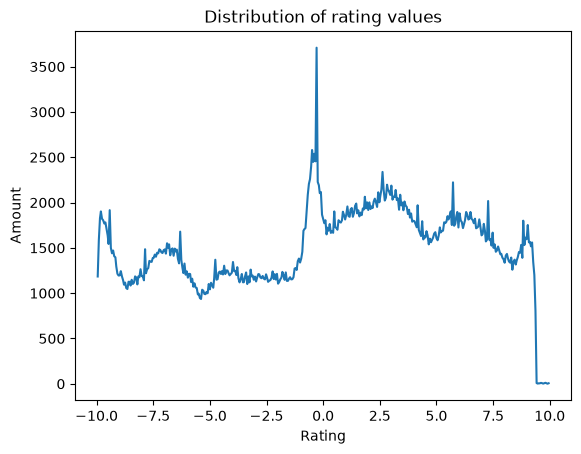

In [37]:
x_range = [r[0] for r in all_ratings_count_2][:-1]
y_range = [r[1] for r in all_ratings_count_2][:-1]
plt.plot(x_range, y_range)
plt.title('Distribution of rating values')
plt.xlabel('Rating')
plt.ylabel('Amount')
plt.show()

In [38]:
negative_ratings_amount = [amount for rating, amount in all_ratings_count_2[:-1] if rating < 0]
positive_ratings_amount = [amount for rating, amount in all_ratings_count_2[:-1] if rating > 0]

p = sum(positive_ratings_amount)
n = sum(negative_ratings_amount)
a = p + n

print(f'All ratings: {a}')
print(f'Positive ratings: {p}, {p/a*100:.2f}% of total')
print(f'Negative ratings: {n}, {n/a*100:.2f}% of total')

All ratings: 615086
Positive ratings: 339221, 55.15% of total
Negative ratings: 275865, 44.85% of total


There are a total of 615091 ratings, with most of them being around 0. There are 339226 positive ratings, being 55.15% of the total and 275865 negative ratings, being 44.85% of the total. The bigger majority of jokes were rated positively.

# 4. RecommenderNet training loss

In [2]:
with open(os.path.join('losses', 'loss_jester_data_1_svd.pkl'), 'rb') as f:
    jester_data_1_sdv_loss = pd.DataFrame(pickle.load(f), columns=['epoch', 'batch', 'loss'])

with open(os.path.join('losses', 'loss_jester_data_2_svd.pkl'), 'rb') as f:
    jester_data_2_sdv_loss = pd.DataFrame(pickle.load(f), columns=['epoch', 'batch', 'loss'])

with open(os.path.join('losses', 'loss_jester_data_comb_svd.pkl'), 'rb') as f:
    jester_data_comb_sdv_loss = pd.DataFrame(pickle.load(f), columns=['epoch', 'batch', 'loss'])

jester_data_1_sdv_loss

,epoch,batch,loss
0,0,0,29.069882
1,0,10,27.494023
2,0,20,25.323789
3,0,30,25.293170
4,0,40,25.719198
...,...,...,...
27495,99,2700,1.549307
27496,99,2710,1.599647
27497,99,2720,1.382075
27498,99,2730,1.257572


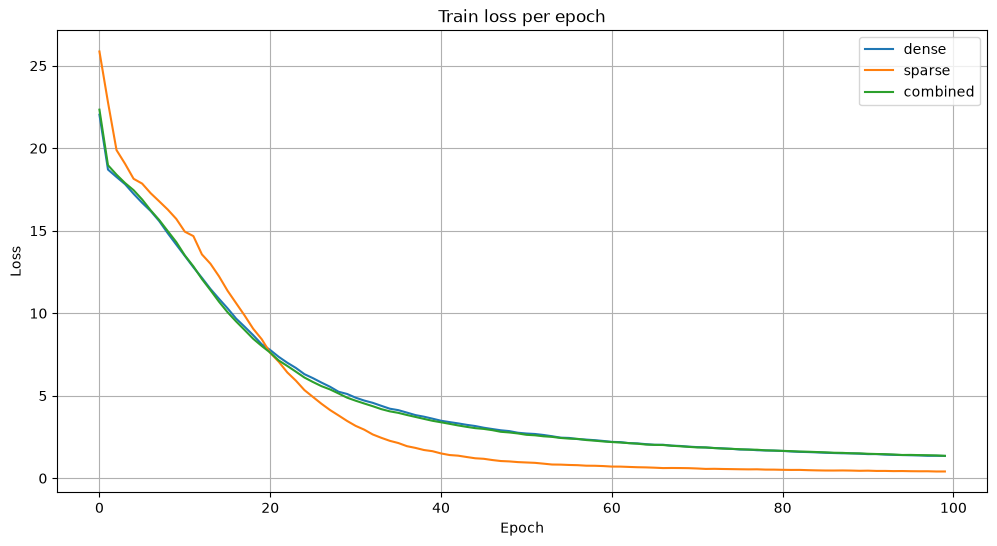

In [3]:
jester_data_1_sdv_loss.groupby('epoch').mean()['loss'].plot(kind='line', figsize=(12, 6), label='dense', legend=True)
jester_data_2_sdv_loss.groupby('epoch').mean()['loss'].plot(kind='line', figsize=(12, 6), label='sparse', legend=True)
jester_data_comb_sdv_loss.groupby('epoch').mean()['loss'].plot(kind='line', figsize=(12, 6), label='combined', legend=True)
plt.title('Train loss per epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

Text(0, 0.5, 'Loss')

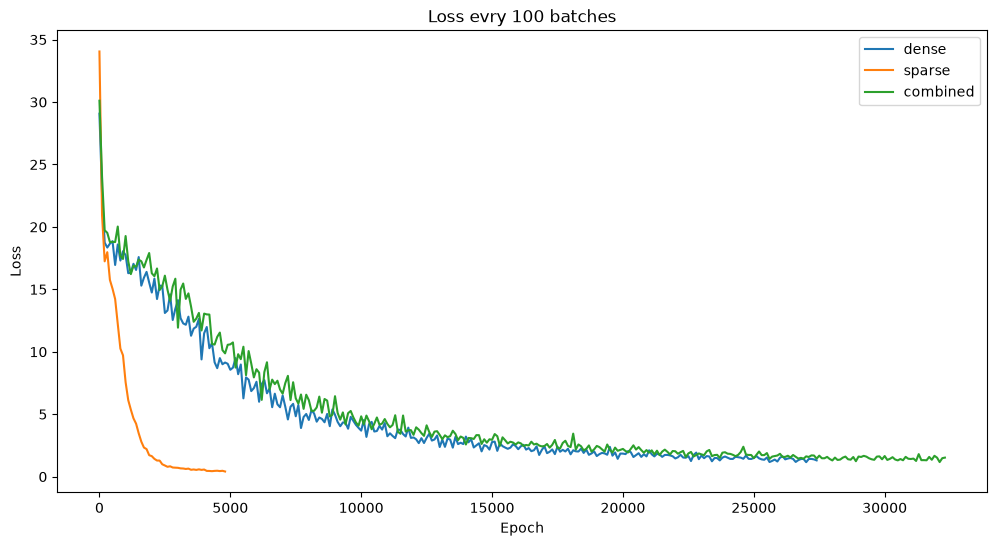

In [4]:
k = 100
jester_data_1_sdv_loss['loss'].iloc[::k].plot(kind='line', figsize=(12, 6), label='dense', legend=True)
jester_data_2_sdv_loss['loss'].iloc[::k].plot(kind='line', figsize=(12, 6), label='sparse', legend=True)
jester_data_comb_sdv_loss['loss'].iloc[::k].plot(kind='line', figsize=(12, 6), label='combined', legend=True)
plt.title('Loss evry 100 batches')
plt.xlabel('Epoch')
plt.ylabel('Loss')

# 5. Formatting data

Some of our prediction models will need a special format for our data that isn't a user x jokes rating matrix, but a list of 'user joke rating'.

In [41]:
jokes_combined_df = pd.concat([jokes_1_df, jokes_2_df]).reset_index(drop=True)
jokes_combined_df.to_csv(os.path.join('data_svd', 'jester_data_comb.csv'), index=False)

In [ ]:
all_ratings_list = []

for index, row in tqdm(jokes_combined_df.iterrows(), total=len(jokes_combined_df)):
    r = row.iloc[1:]
    all_ratings_list.extend(r[~r.isna()])

c = Counter(all_ratings_list)
all_ratings_count_2 = sorted(c.items())

print(len(set(all_ratings_list)))

negative_ratings_amount = [amount for rating, amount in all_ratings_count_2[:-1] if rating < 0]
positive_ratings_amount = [amount for rating, amount in all_ratings_count_2[:-1] if rating > 0]

p = sum(positive_ratings_amount)
n = sum(negative_ratings_amount)
a = p + n

print(f'Density: {a/(len(jokes_combined_df)*100)*100:.2f}%')
print(f'All ratings: {a}')
print(f'Positive ratings: {p}, {p/a*100:.2f}% of total')
print(f'Negative ratings: {n}, {n/a*100:.2f}% of total')

100%|██████████| 73421/73421 [00:16<00:00, 4487.91it/s]

412
Density: 56.17
All ratings: 4123748
Positive ratings: 2418385, 58.65% of total
Negative ratings: 1705363, 41.35% of total


In [27]:
def to_svd(df, file_path, save_to_file=True):
    sdv_format = []

    for user_id, row in tqdm(df.iterrows(), total=len(df)):
        for joke_id, r in row[1:].items():
            if (np.isnan(r)) or (r > 98):
                continue
            sdv_format.append((user_id, joke_id, r))

    if save_to_file is True:
        pd.DataFrame(sdv_format, columns=['user_id', 'joke_id', 'rating']).to_csv(file_path, index=False)

    return sdv_format

In [28]:
sdv_format = to_svd(jokes_1_df, os.path.join('data_svd', 'jester_data_1_svd.csv'), save_to_file=False)

print(f'Ratings: {len(sdv_format)}')
print(sdv_format[:5])
print(sdv_format[-5:])

100%|██████████| 48483/48483 [00:09<00:00, 4859.75it/s]


Ratings: 3519448
[(0, '0', -7.82), (0, '1', 8.79), (0, '2', -9.66), (0, '3', -8.16), (0, '4', -7.52)]
[(48482, '61', -9.95), (48482, '64', -9.81), (48482, '65', 9.32), (48482, '67', 9.32), (48482, '68', 9.32)]


In [29]:
sdv_format = to_svd(jokes_2_df, os.path.join('data_svd', 'jester_data_2_svd.csv'), save_to_file=False)

print(f'Ratings: {len(sdv_format)}')
print(sdv_format[:5])
print(sdv_format[-5:])

100%|██████████| 24938/24938 [00:04<00:00, 5360.02it/s]


Ratings: 616912
[(0, '4', -1.65), (0, '6', -0.78), (0, '7', 6.89), (0, '12', -2.57), (0, '14', -1.31)]
[(24937, '64', 1.36), (24937, '65', 7.18), (24937, '68', 0.49), (24937, '71', 5.87), (24937, '81', 6.65)]


In [30]:
sdv_format = to_svd(jokes_combined_df, os.path.join('data_svd', 'jester_data_comb_svd.csv'), save_to_file=False)

print(f'Ratings: {len(sdv_format)}')
print(sdv_format[:5])
print(sdv_format[-5:])

100%|██████████| 73421/73421 [00:15<00:00, 4658.52it/s]


Ratings: 4136360
[(0, '0', -7.82), (0, '1', 8.79), (0, '2', -9.66), (0, '3', -8.16), (0, '4', -7.52)]
[(73420, '64', 1.36), (73420, '65', 7.18), (73420, '68', 0.49), (73420, '71', 5.87), (73420, '81', 6.65)]


# 6. Conclusions

The ratings are in the continuous range of [-10, 10]. We will have to change the user x jokes rating table format of our datasets. It cannot be used for the SVD algorithm so we have to transform it to a suitable format of 'user_id, joke_id, rating'.

The first 70 jokes have more ratings on average and the models will have better accuracy on them. The last 30 jokes are more sparsely rated. The first jokes dataset is much more dense than the second (75% to 25%) in terms of valid ratings. As such it would give better results when training models by default. Combining the two dataset would balance out the valid ratings and make recommendation more realistic (in real systems users rarely give scores to items) and more challenging.

There are two types of recommender system that we can build with this data:
* recommending jokes based on users with similar taste to our baseline user
* predicting what rating a user will give to an unseen joke based on similar users.

In conclusion, we shall try three different approaches for a recommender system: content-based, collaborative-filtering and deep neural networks. Each has its advantages and disadvantages, complexity, training time needed and scalability. Content-based rec systems include statistical approaches such as predicting mean for each item, TF-IDF and BoW based cosine similarities. Collaborative-filtering rec systems include algorithms such as Singular Value Decomposition and KNN neighborhoods. Deep rec systems use DNN, RNN, Autoencoders, Transformers and other such architectures.

We shall compare how some of these algorithms perform on the Jester Dataset.